# The solow-model for a small open economy   

# OPEN ECONOMY SOLOW MODEL - Capital mobility

## Analytical solution

1. $K_t$ is capital
2. $L_t$ is labor (growing with a constant rate of $n$)
3. $A_t$ is technology (growing with a constant rate of $g$)
4. $Y_t = F(K_t,A_tL_t)$ is GDP
5. $Y=C+I+NX\Leftrightarrow Y+rF=C+NX+rF$ Is the national accounts identity, where $F$ is holdings of foreign capital and $r$ is the real rate of return

6. $NX_{t}+rF=F_{t+1}-F_{t}$
7. $S_{t}=Y_{t}+rF-C_{t}\Leftrightarrow S_{t}=I_{t}+F_{t+1}-F_{t}$ Hence savings can be used to accumulate foreing assets or domestic capital
8. $K_{t+1}=I_{t}+K_{t}\Leftrightarrow K_{t+1}=S_{t}+K_{t}+F_{t}$
9. $V_{t}=K_{t}+F_{t}$ is Wealth


Production is assumed to follow a Cobb-douglas production fucntion:
$$Y_{t}=AK_{t}^{\alpha}L_{t}^{1-\alpha}$$

People save a fraction of the total income: In the open economy

$S_{t}=s(Y_{t}+rF_{t}) $


Capital accumulates as :
$$K_{t+1}^{i}+\bar{K}_{t+1}^{i}=S_{t}+(1-\delta)+K_{t}^{i}+(1-\delta)\bar{K}_{t}^{i}\Leftrightarrow$$
 
$$V_{t+1}=S_{t}+(1-\delta)V_{t} $$

Real rate is :
$$\bar{r}=r_{t}$$
$$r_{t}=B\alpha K_{t}^{\alpha-1}L_{t}^{1-\alpha}$$


## Pr. worker values 

$$k^*=(\frac{B\alpha}{\bar{r}})^{\frac{1}{1-\alpha}}$$
$$y^*=B^{\frac{1}{1-\alpha}}\frac{\alpha}{\bar{r}}^{\frac{\alpha}{1-\alpha}}$$
$$w^*=(1-\alpha)B^{\frac{1}{1-\alpha}} (\frac{\alpha}{\bar{r}})^{\frac{\alpha}{1-\alpha}}$$

## Transition equation

For Wealth:
$$v_{t+1}=\frac{sw^*}{1+n}+\frac{1-\delta+s\bar{r}}{1+n}v_t$$



**Normalizing** $$v_t$$ gives the equation of:
$$v=\frac{sw^*}{1+n}+\frac{1-\delta+s\bar{r}}{1+n}v$$


## Numerical solution

**Firtsly we solve the model, and find the steady state value for wealth**

In [1]:
import numpy as np
import scipy as sp
import sympy as sm

v = sm.symbols('v')
wSS = sm.symbols('w*')
delta = sm.symbols('delta')
s = sm.symbols('s')
r = sm.symbols('r')
n = sm.symbols('n')

In [2]:
ss = sm.Eq(v,((s*wSS/(1+n)+((1-delta+s*r)/(1+n))*v)))
vss = sm.solve(ss,v)[0]
vss

s*w*/(delta + n - r*s)

**We calculate the realwage**

In [3]:
alphaa = 0.3
B = 1
r1 = 0.02

wstar = (1-alphaa)*B**(1/(1-alphaa))*(alphaa/r1)**(alphaa/(1-alphaa))

wstar


2.2342777006521617

**Then we define the solution, as a function**
The calibration values are taken from macro 1 winter exam 2024.

In [4]:
ss_func = sm.lambdify((s,n,r,delta,wSS),vss)

# Evaluate function
ss_func(0.2,0.02,0.02,0.05,2.23)

6.757575757575758

We proceed to solve the steady state using numerical root-finding with optimize.scalar

In [5]:
import scipy.optimize as optimize

s = 0.2
r = 0.02
n = 0.02
delta = 0.05
wss = 2.23

obj_vss = lambda v: v - (((s * wss / (1 + n) + ((1 - delta + s * r) / (1 + n)) * v)))
result = optimize.root_scalar(obj_vss, bracket=[0.1, 100], method='brentq')

print('The steady state for v is', result.root)

The steady state for v is 6.7575757575757445


**We note that the solutions are identical we have therefore found the steady state values**

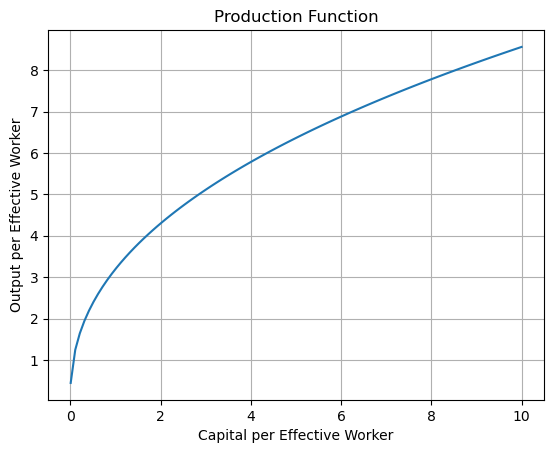

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
s = 0.2
r = 0.02
n = 0.02
delta = 0.05
wss = 2.23
A = 1  # Let's assume TFP (A) is 1 for simplicity - as in the book of H.J Whitta and P.B. Sørensen

# Steady state capital per effective worker
vss = 6.75 

# Production function
def production_function(v, A, alpha, r):
    return A**(1/(1-alpha)) * (v * alpha/r)**(alpha/(1-alpha))

# Define range for capital per effective worker (v)
v_values = np.linspace(0.01, 10, 100)  # Adjust the range as needed

# Calculate output for each value of capital per effective worker
output_values = production_function(v_values, A, 0.3, r)  # Assuming alpha is 0.3

# Plotting
plt.plot(v_values, output_values)
plt.title('Production Function')
plt.xlabel('Capital per Effective Worker')
plt.ylabel('Output per Effective Worker')
plt.grid(True)
plt.show()


We note that the open solow model explores diminishing return to scale. 

## Wealth accumulation in the open economy:

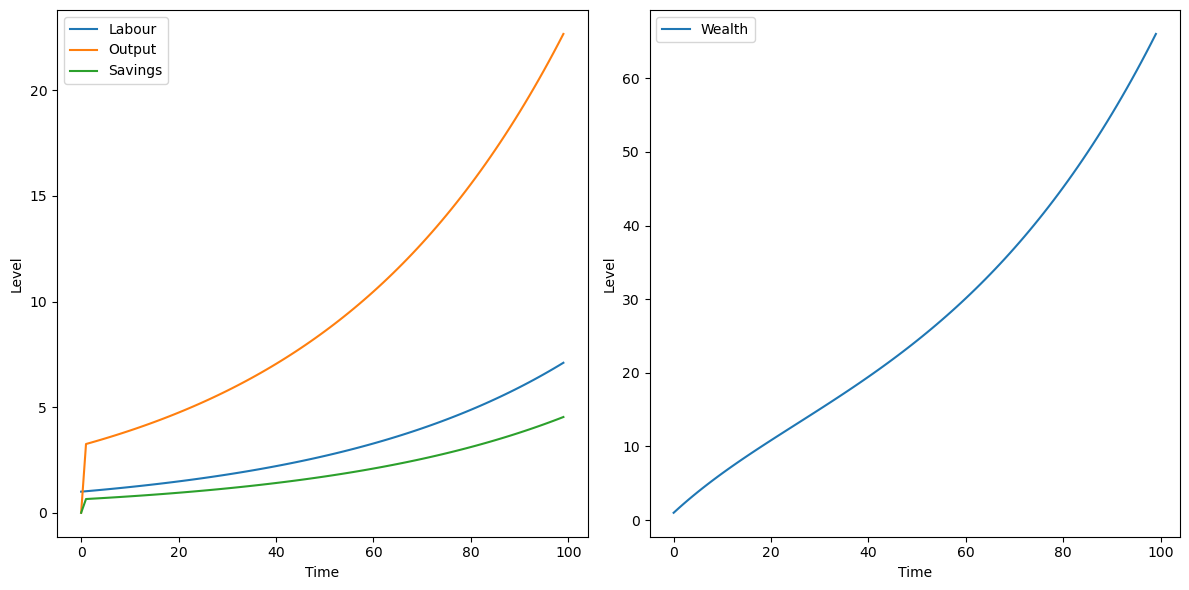

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

#  We define parameters of the model. Note all parameter values are obtained from the vinter 2023 macro I exam

alpha = 0.3  
n = 0.02  
g = 0.03  
r_bar = 0.02  
B = 1

# Initial conditions for wealth and labour
V0 = 1.0  
L0 = 1.0  

T = 100  # Number of periods to simulate

# We proceed to simulate the open Solow model
K = np.zeros(T)
Y = np.zeros(T)
L = np.zeros(T)
V = np.zeros(T)
S = np.zeros(T)
    
L[0] = L0
V[0] = V0
    
for t in range(1, T):
        L[t] = L[t-1] * (1 + n)
        K[t] = (B*alpha/r_bar)**(1/(1-alpha)) * L[t]
        Y[t] = B*(K[t]**alpha) * L[t]**(1-alpha)
        S[t] = s * Y[t]
        V[t] = S[t] + (1 - delta) * V[t-1]
        
    # Plotting the results
time = np.arange(T)
    
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(time, L, label='Labour')
plt.plot(time, Y, label='Output')
plt.plot(time, S, label='Savings')
plt.xlabel('Time')
plt.ylabel('Level')
plt.legend()
    
plt.subplot(1, 2, 2)
plt.plot(time, V, label='Wealth')
plt.xlabel('Time')
plt.ylabel('Level')
plt.legend()
    
plt.tight_layout()
plt.show()

# Further analysis

In this part, we illustrate how the model changes with parameter values and how different shocks affect our model

The following code down below will show different scenarios of the savings rate, $s$. Hereby we can see this parameters impact on the wealth in the economy. Likewise, we consider canges of the depreciation rate $\delta$. 

In [8]:
from ipywidgets import interact
import ipywidgets as widgets

alpha = 0.3  
n = 0.02  
g = 0.03  
r_bar = 0.02  
B = 1

# Initial conditions
V0 = 1.0  
L0 = 1.0  

T = 100  

def solow_model(delta, s):
    K = np.zeros(T)
    Y = np.zeros(T)
    L = np.zeros(T)
    V = np.zeros(T)
    S = np.zeros(T)
    
    L[0] = L0
    V[0] = V0
    
    for t in range(1, T):
        L[t] = L[t-1] * (1 + n)
        K[t] = (B*alpha/r_bar)**(1/(1-alpha)) * L[t]
        Y[t] = B*(K[t]**alpha) * L[t]**(1-alpha)
        S[t] = s * Y[t]
        V[t] = S[t] + (1 - delta) * V[t-1]
    
    
    time = np.arange(T)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(time, L, label='Labour')
    plt.plot(time, Y, label='Output')
    plt.plot(time, S, label='Savings')
    plt.xlabel('Time')
    plt.ylabel('Level')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(time, V, label='Wealth')
    plt.xlabel('Time')
    plt.ylabel('Level')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# We create sliders for the parameters of the model
delta_slider = widgets.FloatSlider(min=0.01, max=0.1, step=0.01, value=0.05, description='Delta')
s_slider = widgets.FloatSlider(min=0.01, max=0.5, step=0.01, value=0.2, description='Savings Rate')


interact(solow_model, delta=delta_slider, s=s_slider)


interactive(children=(FloatSlider(value=0.05, description='Delta', max=0.1, min=0.01, step=0.01), FloatSlider(…

<function __main__.solow_model(delta, s)>

This graph demonstrates that as the savings rate increases, the wealth accumulation remains increases in levels for a given capital level (could easily be extended to per effective worker). It highlights the positive correlation between savings rate and wealth, emphasizing that higher savings facilitate greater capital accumulation in the economy. Further note, that the overall savings in the economy increases as savigns rate increases.

The plot shows the negative impact of higher depreciation rates on wealth accumulation. As the depreciation rate increases, wealth accumulation decreases for each level of capital, illustrating the detrimental effect of higher capital erosion on the economy's ability to generate and sustain wealth.

## The following code shows a positive shock to the productivity in the economy

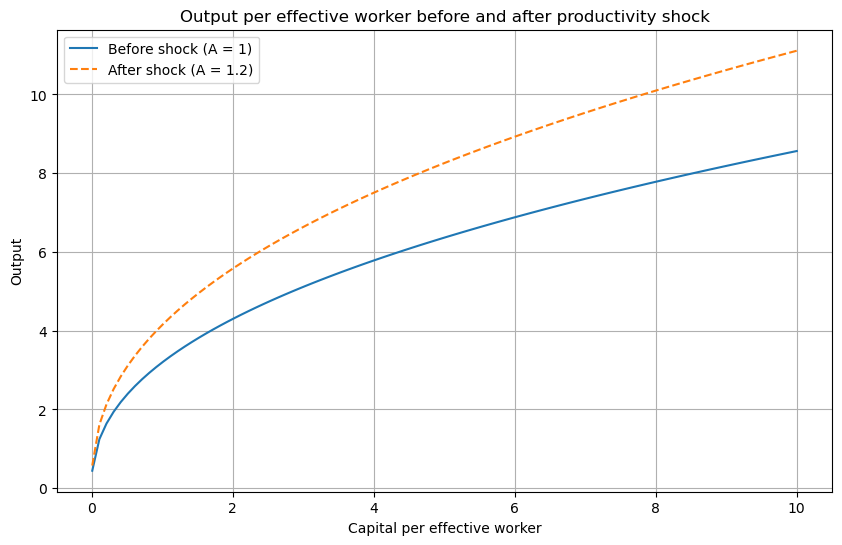

In [9]:
# Adjusted production function to include productivity
def production_function(v, A, alpha, r):
    return A**(1/(1-alpha)) * (v * alpha/r)**(alpha/(1-alpha))

# Parameters before and after the productivity shock
A_before = 1  # Productivity before the shock
A_after = 1.2  # Productivity after the shock (shock scenario)

# Calculate output for each value of capital per effective worker before and after the shock
output_values_before = production_function(v_values, A_before, 0.3, r)
output_values_after = production_function(v_values, A_after, 0.3, r)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(v_values, output_values_before, label=f'Before shock (A = {A_before})')
plt.plot(v_values, output_values_after, label=f'After shock (A = {A_after})', linestyle='--')

plt.title('Output per effective worker before and after productivity shock')
plt.xlabel('Capital per effective worker')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()


This graph displays the impact of a productivity shock on the economy. An increase in productivity leads to a marked rise in the output per effective worker, demonstrating the critical role of technological advancements and efficiency improvements in enhancing economic output and overall economic health.

# Conclusion

We conclude that the numerical steady state value for wealth is 6,75. We see that $y_t^*$ has diminishing return of scale, and that a positive schock to technology, will give a higher output pr. person. We also investigate the effects of different savings and depreciation rates. The analysis reveals that higher depreciation rates leads to lower wealth accumulation in the economy. Further we observe a positive impact of savingsrate is transmitted onto wealth acumulation. 